[INIT] 当前运行设备: cuda:1
[LOAD] Model: checkpoints_01/epoch200_20260130_120009/model.pt


/tmp/ipykernel_1195538/3209189697.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CKPT_PATH, map_location=device)


[INFO] Phantom声源点数: 33554
[LOAD] 信号数据加载完毕，形状: torch.Size([65, 1048])
[LOAD] 初始阵列坐标加载完毕: torch.Size([65, 3])

开始刚体阵列精细校准 (Micro-Batch Size: 5)
Epoch 0000 | Loss: 0.547848 | dRot(deg): [0.006, -0.006, -0.006] | dTrans(mm): [-0.100, -0.100, 0.100]
Epoch 0002 | Loss: 0.240457 | dRot(deg): [0.013, -0.012, -0.017] | dTrans(mm): [-0.237, -0.294, 0.209]
Epoch 0004 | Loss: 0.263963 | dRot(deg): [0.010, -0.009, -0.027] | dTrans(mm): [-0.180, -0.398, 0.141]
Epoch 0006 | Loss: 0.200592 | dRot(deg): [0.008, -0.007, -0.033] | dTrans(mm): [-0.062, -0.402, 0.108]
Epoch 0008 | Loss: 0.187475 | dRot(deg): [0.010, -0.009, -0.035] | dTrans(mm): [0.030, -0.374, 0.146]

[DONE] 优化耗时: 27.9s


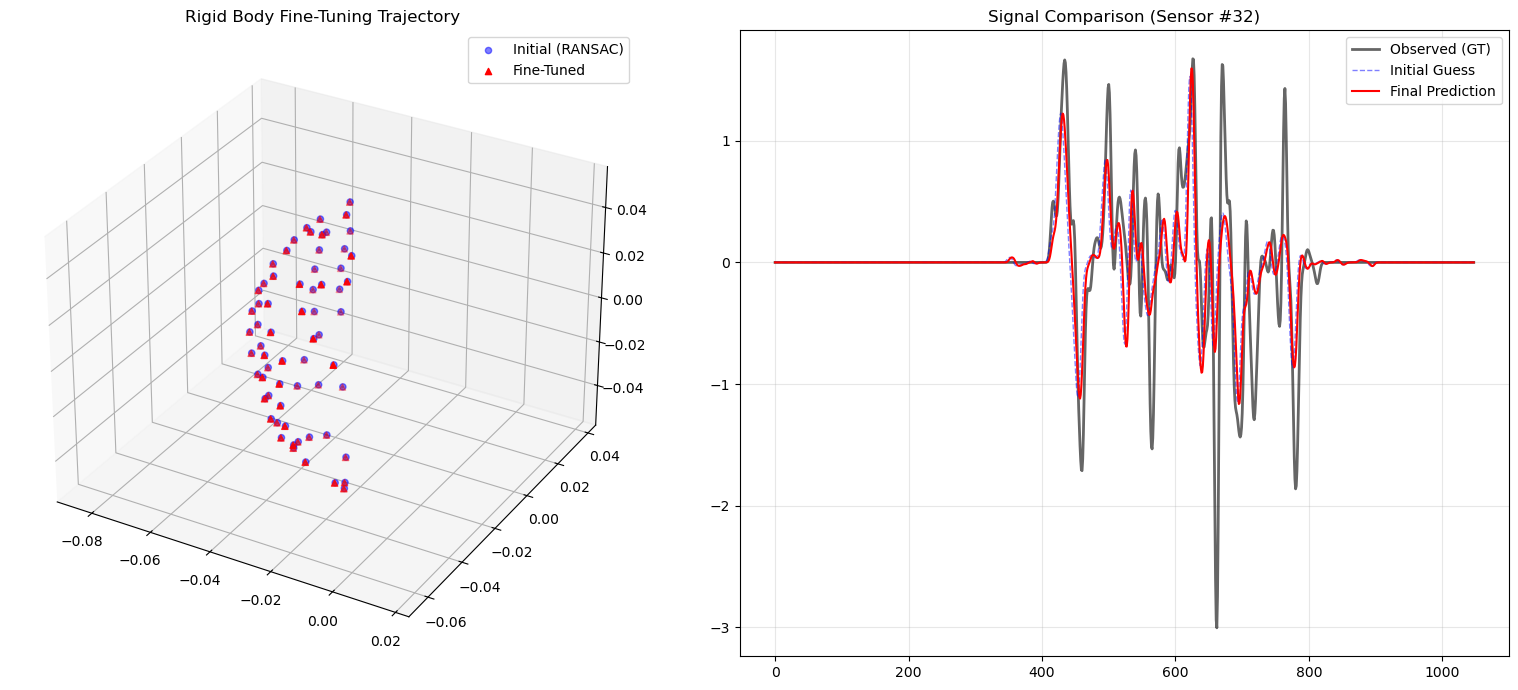


最终校准统计 (Statistics)
Mean Shift: 0.4054 mm
Max Shift : 0.4262 mm
Final Loss (1-Corr): 0.212588

Final Global Transform applied to Initial Guess:
Rotation (rad) : [ 0.00020279 -0.00017629 -0.00060956]
Translation (m): [ 4.4516910e-05 -3.6704660e-04  1.6523116e-04]

[SAVE] 结果已保存至: predicted_array_location_finetuned.txt


In [1]:
import os
import time
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ===============================================================
# 配置与初始化
# ===============================================================
DEVICE_ID = 1
device = torch.device(f"cuda:{DEVICE_ID}" if torch.cuda.is_available() else "cpu")
print(f"[INIT] 当前运行设备: {device}")

# --- 声学参数 ---
vs = 1500.0             # 声速
delta_time = 25e-9      # 采样间隔
t_start_idx = 1000      # 截取起始点
t_end_idx   = 2048      # 截取结束点
n_time_sub = t_end_idx - t_start_idx

# --- 优化参数 ---
TOTAL_EPOCHS = 10      # 迭代次数
LR_ROT       = 1e-4      # 旋转学习率 (Radians)
LR_TRANS     = 1e-4      # 平移学习率 (Meters)
SIGMA_FIXED  = 0.1e-3    # 0.1mm 的声源宽度，用于精细对齐

# --- 显存优化参数 ---
# 如果显存 < 8GB，建议设为 1 或 2
# 如果显存 > 12GB，建议设为 5 或 10
MICRO_BATCH_SIZE = 5     

# ===============================================================
# 1. 数据加载
# ===============================================================
signal_path = "data/simulated_signal_rotated_120.txt"
init_array_path = "predicted_array_location_corrected.txt" # RANSAC 结果
CKPT_PATH = "checkpoints_01/epoch200_20260130_120009/model.pt" 
KEEP_RATIO = 0.002     

# --- A. 加载 Phantom 模型 ---
if os.path.exists(CKPT_PATH):
    print(f"[LOAD] Model: {CKPT_PATH}")
    ckpt = torch.load(CKPT_PATH, map_location=device)
    Pc_raw = ckpt["Pc_state"].to(device).contiguous().requires_grad_(False)
    
    GRID_SIZE = 256
    coords = (np.arange(GRID_SIZE) - (GRID_SIZE-1)/2.0) * 0.1e-3 
    xg, yg, zg = np.meshgrid(coords, coords, coords, indexing="ij")
    
    src_x_raw = torch.tensor(xg.ravel(), device=device, dtype=torch.float32).contiguous()
    src_y_raw = torch.tensor(yg.ravel(), device=device, dtype=torch.float32).contiguous()
    src_z_raw = torch.tensor(zg.ravel(), device=device, dtype=torch.float32).contiguous()
    
    n_keep = int(Pc_raw.numel() * KEEP_RATIO)
    val_top, idx_top = torch.topk(torch.abs(Pc_raw), n_keep)
    
    Pc_fixed = Pc_raw[idx_top].contiguous()
    xyz_src = torch.stack([src_x_raw[idx_top], src_y_raw[idx_top], src_z_raw[idx_top]], dim=1).contiguous()
    print(f"[INFO] Phantom声源点数: {xyz_src.shape[0]}")
else:
    raise FileNotFoundError(f"找不到模型文件: {CKPT_PATH}")

# --- B. 加载观测信号 ---
if os.path.exists(signal_path):
    signals_full_raw = np.loadtxt(signal_path)
    # 下采样：129 -> 65
    sel_step = 2
    sel_idx = np.arange(0, signals_full_raw.shape[0], sel_step)
    signals_sub_raw = signals_full_raw[sel_idx] 
    # 截取时间窗
    signals_target = torch.tensor(signals_sub_raw[:, t_start_idx:t_end_idx], dtype=torch.float32, device=device)
    print(f"[LOAD] 信号数据加载完毕，形状: {signals_target.shape}")
else:
    raise FileNotFoundError(f"找不到信号文件: {signal_path}")

# --- C. 加载初始位置 (RANSAC Corrected) ---
if os.path.exists(init_array_path):
    # 自动跳过可能的 header ('#')
    init_pos_np = np.loadtxt(init_array_path)
    if init_pos_np.shape[0] != signals_target.shape[0]:
        raise ValueError(f"坐标数量 ({init_pos_np.shape[0]}) 与 信号数量 ({signals_target.shape[0]}) 不匹配！")
    init_pos_tensor = torch.tensor(init_pos_np, dtype=torch.float32, device=device)
    print(f"[LOAD] 初始阵列坐标加载完毕: {init_pos_tensor.shape}")
else:
    raise FileNotFoundError(f"找不到初始坐标文件: {init_array_path}")

# ===============================================================
# 2. 核心函数与模型
# ===============================================================

def build_rotation_matrix(r):
    """构建旋转矩阵 (Euler Z-Y-X)"""
    cx, sx = torch.cos(r[0]), torch.sin(r[0])
    cy, sy = torch.cos(r[1]), torch.sin(r[1])
    cz, sz = torch.cos(r[2]), torch.sin(r[2])

    Rx = torch.stack([torch.tensor([1.,0,0], device=device), 
                      torch.stack([torch.tensor(0., device=device), cx, -sx]), 
                      torch.stack([torch.tensor(0., device=device), sx, cx])])
    Ry = torch.stack([torch.stack([cy, torch.tensor(0., device=device), sy]), 
                      torch.tensor([0.,1,0], device=device), 
                      torch.stack([-sy, torch.tensor(0., device=device), cy])])
    Rz = torch.stack([torch.stack([cz, -sz, torch.tensor(0., device=device)]), 
                      torch.stack([sz, cz, torch.tensor(0., device=device)]), 
                      torch.tensor([0.,0,1], device=device)])
    
    return Rz @ Ry @ Rx

def vectorized_acoustic_simulation(sens_pos_batch, src_pos, Pc, t_start, n_time, dt, vs, a):
    """
    全矩阵计算声场
    sens_pos_batch: (Batch, 3)
    src_pos: (N_src, 3)
    Returns: (Batch, n_time)
    """
    # 1. 距离矩阵 (Batch, N_src)
    diff = sens_pos_batch.unsqueeze(1) - src_pos.unsqueeze(0) 
    r = torch.norm(diff, dim=2) + 1e-12 
    
    # 2. 时间向量 (T,)
    t_global = t_start + torch.arange(n_time, device=device, dtype=torch.float32) 
    
    # 3. 核心大张量: 距离-时间差 (Batch, N_src, T)
    # 注意：这一步最吃显存
    rt = r.unsqueeze(2) - vs * (t_global * dt).reshape(1, 1, -1)
    
    # 4. 高斯与幅度
    exponent = torch.exp( - (rt**2) / (2.0 * a * a) )
    amplitude = Pc.reshape(1, -1, 1) * 0.5 * (rt / r.unsqueeze(2))
    
    # 5. 积分/求和 -> (Batch, T)
    signals = torch.sum(amplitude * exponent, dim=1)
    return signals

def batch_negative_correlation_loss(pred_batch, target_batch):
    """计算批次平均负相关 Loss"""
    pred_mean = pred_batch - pred_batch.mean(dim=1, keepdim=True)
    target_mean = target_batch - target_batch.mean(dim=1, keepdim=True)
    numerator = torch.sum(pred_mean * target_mean, dim=1)
    d1 = torch.norm(pred_mean, dim=1)
    d2 = torch.norm(target_mean, dim=1)
    correlation = numerator / (d1 * d2 + 1e-9)
    return 1.0 - correlation.mean()

class RigidArrayOptimizer(nn.Module):
    def __init__(self, init_points):
        super().__init__()
        # 计算几何中心
        self.centroid = torch.mean(init_points, dim=0, keepdim=True).detach()
        # 存储相对中心的坐标 (固定形状)
        self.points_centered = (init_points - self.centroid).detach()
        
        # 优化参数: 3个旋转角, 3个平移分量
        self.rot_euler = nn.Parameter(torch.zeros(3, device=device)) 
        self.trans_vec = nn.Parameter(torch.zeros(3, device=device))
        
    def forward(self):
        R = build_rotation_matrix(self.rot_euler)
        # 旋转 + 移回原位 + 修正平移
        p_final = (self.points_centered @ R.T) + self.centroid + self.trans_vec
        return p_final

# ===============================================================
# 3. 训练循环 (显存安全版 - Gradient Accumulation)
# ===============================================================
print("\n" + "="*80)
print(f"开始刚体阵列精细校准 (Micro-Batch Size: {MICRO_BATCH_SIZE})")
print("="*80)

model = RigidArrayOptimizer(init_pos_tensor).to(device)
optimizer = torch.optim.Adam([
    {'params': model.rot_euler, 'lr': LR_ROT},
    {'params': model.trans_vec, 'lr': LR_TRANS}
])

loss_history = []
start_time = time.time()

for epoch in range(TOTAL_EPOCHS):
    optimizer.zero_grad()
    
    # 1. 获得当前所有探头的位置 (计算量极小，只保留 Parameter 的梯度图)
    current_pos_all = model()
    
    total_loss_val = 0.0
    num_sensors = current_pos_all.shape[0]
    
    # 2. 梯度累加循环 (空间换显存)
    for i in range(0, num_sensors, MICRO_BATCH_SIZE):
        end_idx = min(i + MICRO_BATCH_SIZE, num_sensors)
        
        # 切片
        pos_batch = current_pos_all[i:end_idx]       # (MicroBatch, 3)
        target_batch = signals_target[i:end_idx]     # (MicroBatch, Time)
        
        # 前向模拟 (产生巨大张量，但仅限于 MicroBatch 大小)
        pred_batch = vectorized_acoustic_simulation(
            pos_batch, xyz_src, Pc_fixed, 
            t_start_idx, n_time_sub, delta_time, vs, a=SIGMA_FIXED
        )
        
        # 计算 Loss 片段
        loss_fragment = batch_negative_correlation_loss(pred_batch, target_batch)
        
        # 加权 (因为 loss 是 mean，总梯度应该是各部分梯度的加权和)
        # weight = (batch_size / total_size)
        weight = (end_idx - i) / num_sensors
        weighted_loss = loss_fragment * weight
        
        # 反向传播 (retain_graph=True 是必须的，因为 current_pos_all 依赖共享参数)
        # 但 weighted_loss 的中间计算图 (Simulation部分) 会在 backward 后释放
        weighted_loss.backward(retain_graph=True)
        
        total_loss_val += weighted_loss.item()
        
        # 显式清理
        del pred_batch, loss_fragment, weighted_loss
    
    # 3. 更新参数
    optimizer.step()
    
    # 清理整个 Epoch 的中间变量
    del current_pos_all
    
    loss_history.append(total_loss_val)
    
    if epoch % 2 == 0:
        r_deg = model.rot_euler.detach().cpu().numpy() * 180 / np.pi
        t_mm = model.trans_vec.detach().cpu().numpy() * 1000
        print(f"Epoch {epoch:04d} | Loss: {total_loss_val:.6f} | "
              f"dRot(deg): [{r_deg[0]:.3f}, {r_deg[1]:.3f}, {r_deg[2]:.3f}] | "
              f"dTrans(mm): [{t_mm[0]:.3f}, {t_mm[1]:.3f}, {t_mm[2]:.3f}]")

print(f"\n[DONE] 优化耗时: {time.time()-start_time:.1f}s")

# ===============================================================
# 4. 结果可视化与保存
# ===============================================================
final_pos_tensor = model().detach()
final_pos_np = final_pos_tensor.cpu().numpy()
init_pos_np_cpu = init_pos_tensor.cpu().numpy()

# 4.1 生成最终信号用于对比 (仅生成几个用于绘图，防止 OOM)
with torch.no_grad():
    idx_sample = 32 # 取中间的一个探头
    sample_pos = final_pos_tensor[idx_sample:idx_sample+1]
    sample_sig_target = signals_target[idx_sample].cpu().numpy()
    
    sample_sig_pred = vectorized_acoustic_simulation(
        sample_pos, xyz_src, Pc_fixed, 
        t_start_idx, n_time_sub, delta_time, vs, a=SIGMA_FIXED
    ).cpu().numpy()[0]
    
    sample_pos_init = init_pos_tensor[idx_sample:idx_sample+1]
    sample_sig_init = vectorized_acoustic_simulation(
        sample_pos_init, xyz_src, Pc_fixed, 
        t_start_idx, n_time_sub, delta_time, vs, a=SIGMA_FIXED
    ).cpu().numpy()[0]

# 4.2 绘图
fig = plt.figure(figsize=(16, 7))

# 3D 轨迹图
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(init_pos_np_cpu[:,0], init_pos_np_cpu[:,1], init_pos_np_cpu[:,2], c='blue', alpha=0.5, label='Initial (RANSAC)')
ax1.scatter(final_pos_np[:,0], final_pos_np[:,1], final_pos_np[:,2], c='red', marker='^', label='Fine-Tuned')
# 绘制连线
for i in range(len(final_pos_np)):
    ax1.plot([init_pos_np_cpu[i,0], final_pos_np[i,0]], 
             [init_pos_np_cpu[i,1], final_pos_np[i,1]], 
             [init_pos_np_cpu[i,2], final_pos_np[i,2]], 'k-', alpha=0.3)

# 设置轴比例相等 (防止视觉变形)
limits = np.array([ax1.get_xlim3d(), ax1.get_ylim3d(), ax1.get_zlim3d()])
origin = np.mean(limits, axis=1)
radius = 0.5 * np.max(np.abs(limits[:, 1] - limits[:, 0]))
ax1.set_xlim3d([origin[0] - radius, origin[0] + radius])
ax1.set_ylim3d([origin[1] - radius, origin[1] + radius])
ax1.set_zlim3d([origin[2] - radius, origin[2] + radius])
ax1.set_title("Rigid Body Fine-Tuning Trajectory")
ax1.legend()

# 信号对比图
ax2 = fig.add_subplot(1, 2, 2)
t_axis = np.arange(n_time_sub)
ax2.plot(t_axis, sample_sig_target, 'k', linewidth=2, alpha=0.6, label='Observed (GT)')
ax2.plot(t_axis, sample_sig_init, 'b--', linewidth=1, alpha=0.5, label='Initial Guess')
ax2.plot(t_axis, sample_sig_pred, 'r', linewidth=1.5, label='Final Prediction')
ax2.set_title(f"Signal Comparison (Sensor #{idx_sample})")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4.3 统计与保存
diff = final_pos_np - init_pos_np_cpu
dist = np.linalg.norm(diff, axis=1) * 1000 # mm

print("\n" + "="*40)
print("最终校准统计 (Statistics)")
print("="*40)
print(f"Mean Shift: {np.mean(dist):.4f} mm")
print(f"Max Shift : {np.max(dist):.4f} mm")
print(f"Final Loss (1-Corr): {loss_history[-1]:.6f}")

r_final = model.rot_euler.detach().cpu().numpy()
t_final = model.trans_vec.detach().cpu().numpy()
print(f"\nFinal Global Transform applied to Initial Guess:")
print(f"Rotation (rad) : {r_final}")
print(f"Translation (m): {t_final}")

save_final_name = "predicted_array_location_finetuned.txt"
np.savetxt(save_final_name, final_pos_np, fmt='%.8f', header="Finetuned x, y, z (meters)")
print(f"\n[SAVE] 结果已保存至: {save_final_name}")

[INIT] 当前运行设备: cuda:1
[LOAD] Model: checkpoints_01/epoch200_20260130_120009/model.pt


/tmp/ipykernel_1197773/3404478832.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CKPT_PATH, map_location=device)


[INFO] Phantom声源点数: 33554
[LOAD] 信号数据加载完毕，形状: torch.Size([65, 1048])
[LOAD] 初始阵列坐标加载完毕: torch.Size([65, 3])

开始刚体阵列精细校准 (Micro-Batch Size: 5)
Epoch 0000 | Loss: 0.547848 | dRot(deg): [0.006, -0.006, -0.006] | dTrans(mm): [-0.100, -0.100, 0.100]
Epoch 0002 | Loss: 0.240457 | dRot(deg): [0.013, -0.012, -0.017] | dTrans(mm): [-0.237, -0.294, 0.209]
Epoch 0004 | Loss: 0.263963 | dRot(deg): [0.010, -0.009, -0.027] | dTrans(mm): [-0.180, -0.398, 0.141]
Epoch 0006 | Loss: 0.200592 | dRot(deg): [0.008, -0.007, -0.033] | dTrans(mm): [-0.062, -0.402, 0.108]
Epoch 0008 | Loss: 0.187475 | dRot(deg): [0.010, -0.009, -0.035] | dTrans(mm): [0.030, -0.374, 0.146]
Epoch 0010 | Loss: 0.229024 | dRot(deg): [0.012, -0.011, -0.035] | dTrans(mm): [0.039, -0.367, 0.171]
Epoch 0012 | Loss: 0.204430 | dRot(deg): [0.011, -0.010, -0.033] | dTrans(mm): [-0.012, -0.383, 0.148]
Epoch 0014 | Loss: 0.173751 | dRot(deg): [0.010, -0.009, -0.030] | dTrans(mm): [-0.081, -0.392, 0.123]
Epoch 0016 | Loss: 0.180960 | dRot(d

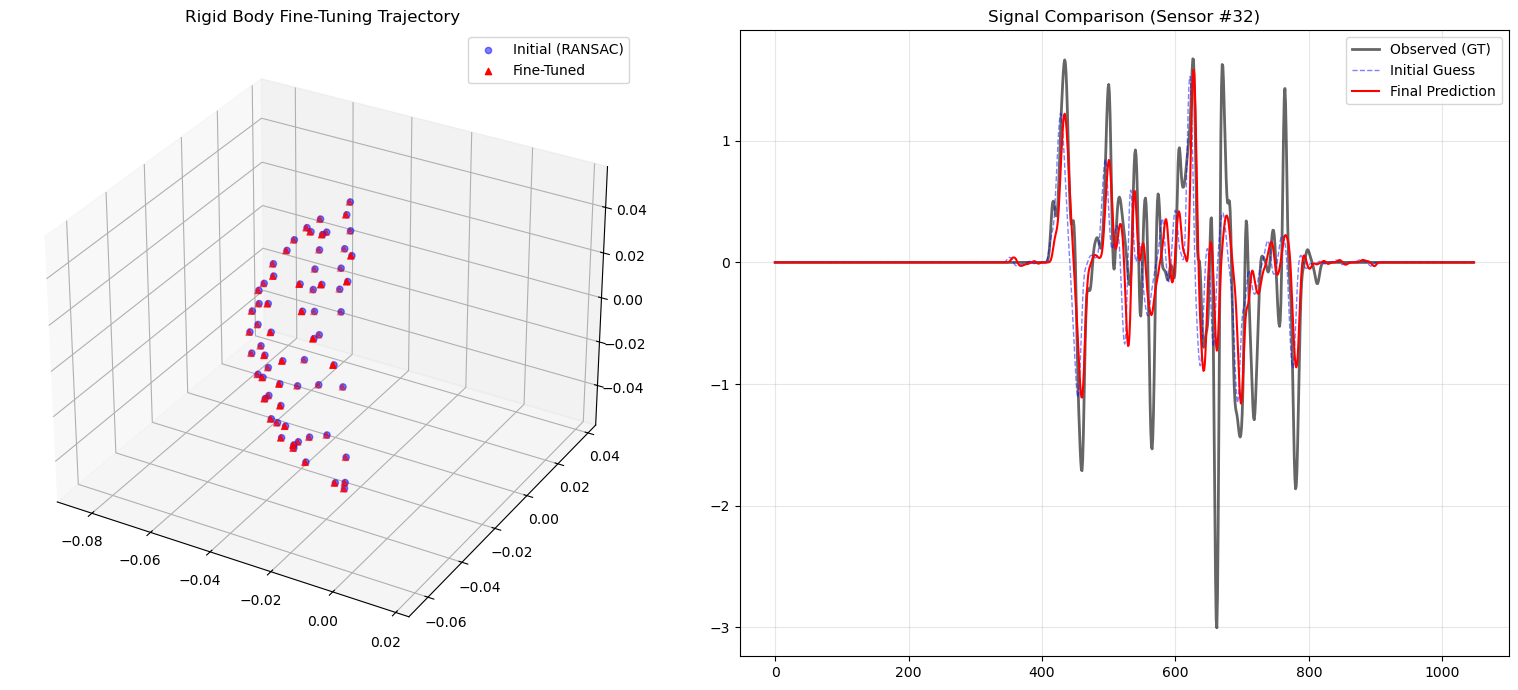


最终校准统计 (Statistics)
Mean Shift: 0.3732 mm
Max Shift : 0.4193 mm
Final Loss (1-Corr): 0.165586

Final Global Transform applied to Initial Guess:
Rotation (rad) : [ 0.0006401  -0.00044376 -0.00050636]
Translation (m): [-8.1707811e-05 -3.4115478e-04  1.2554084e-04]

[SAVE] 结果已保存至: predicted_array_location_finetuned_100.txt


In [1]:
import os
import time
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ===============================================================
# 配置与初始化
# ===============================================================
DEVICE_ID = 1
device = torch.device(f"cuda:{DEVICE_ID}" if torch.cuda.is_available() else "cpu")
print(f"[INIT] 当前运行设备: {device}")

# --- 声学参数 ---
vs = 1500.0             # 声速
delta_time = 25e-9      # 采样间隔
t_start_idx = 1000      # 截取起始点
t_end_idx   = 2048      # 截取结束点
n_time_sub = t_end_idx - t_start_idx

# --- 优化参数 ---
TOTAL_EPOCHS = 100      # 迭代次数
LR_ROT       = 1e-4      # 旋转学习率 (Radians)
LR_TRANS     = 1e-4      # 平移学习率 (Meters)
SIGMA_FIXED  = 0.1e-3    # 0.1mm 的声源宽度，用于精细对齐

# --- 显存优化参数 ---
# 如果显存 < 8GB，建议设为 1 或 2
# 如果显存 > 12GB，建议设为 5 或 10
MICRO_BATCH_SIZE = 5     

# ===============================================================
# 1. 数据加载
# ===============================================================
signal_path = "data/simulated_signal_rotated_120.txt"
init_array_path = "predicted_array_location_corrected.txt" # RANSAC 结果
CKPT_PATH = "checkpoints_01/epoch200_20260130_120009/model.pt" 
KEEP_RATIO = 0.002     

# --- A. 加载 Phantom 模型 ---
if os.path.exists(CKPT_PATH):
    print(f"[LOAD] Model: {CKPT_PATH}")
    ckpt = torch.load(CKPT_PATH, map_location=device)
    Pc_raw = ckpt["Pc_state"].to(device).contiguous().requires_grad_(False)
    
    GRID_SIZE = 256
    coords = (np.arange(GRID_SIZE) - (GRID_SIZE-1)/2.0) * 0.1e-3 
    xg, yg, zg = np.meshgrid(coords, coords, coords, indexing="ij")
    
    src_x_raw = torch.tensor(xg.ravel(), device=device, dtype=torch.float32).contiguous()
    src_y_raw = torch.tensor(yg.ravel(), device=device, dtype=torch.float32).contiguous()
    src_z_raw = torch.tensor(zg.ravel(), device=device, dtype=torch.float32).contiguous()
    
    n_keep = int(Pc_raw.numel() * KEEP_RATIO)
    val_top, idx_top = torch.topk(torch.abs(Pc_raw), n_keep)
    
    Pc_fixed = Pc_raw[idx_top].contiguous()
    xyz_src = torch.stack([src_x_raw[idx_top], src_y_raw[idx_top], src_z_raw[idx_top]], dim=1).contiguous()
    print(f"[INFO] Phantom声源点数: {xyz_src.shape[0]}")
else:
    raise FileNotFoundError(f"找不到模型文件: {CKPT_PATH}")

# --- B. 加载观测信号 ---
if os.path.exists(signal_path):
    signals_full_raw = np.loadtxt(signal_path)
    # 下采样：129 -> 65
    sel_step = 2
    sel_idx = np.arange(0, signals_full_raw.shape[0], sel_step)
    signals_sub_raw = signals_full_raw[sel_idx] 
    # 截取时间窗
    signals_target = torch.tensor(signals_sub_raw[:, t_start_idx:t_end_idx], dtype=torch.float32, device=device)
    print(f"[LOAD] 信号数据加载完毕，形状: {signals_target.shape}")
else:
    raise FileNotFoundError(f"找不到信号文件: {signal_path}")

# --- C. 加载初始位置 (RANSAC Corrected) ---
if os.path.exists(init_array_path):
    # 自动跳过可能的 header ('#')
    init_pos_np = np.loadtxt(init_array_path)
    if init_pos_np.shape[0] != signals_target.shape[0]:
        raise ValueError(f"坐标数量 ({init_pos_np.shape[0]}) 与 信号数量 ({signals_target.shape[0]}) 不匹配！")
    init_pos_tensor = torch.tensor(init_pos_np, dtype=torch.float32, device=device)
    print(f"[LOAD] 初始阵列坐标加载完毕: {init_pos_tensor.shape}")
else:
    raise FileNotFoundError(f"找不到初始坐标文件: {init_array_path}")

# ===============================================================
# 2. 核心函数与模型
# ===============================================================

def build_rotation_matrix(r):
    """构建旋转矩阵 (Euler Z-Y-X)"""
    cx, sx = torch.cos(r[0]), torch.sin(r[0])
    cy, sy = torch.cos(r[1]), torch.sin(r[1])
    cz, sz = torch.cos(r[2]), torch.sin(r[2])

    Rx = torch.stack([torch.tensor([1.,0,0], device=device), 
                      torch.stack([torch.tensor(0., device=device), cx, -sx]), 
                      torch.stack([torch.tensor(0., device=device), sx, cx])])
    Ry = torch.stack([torch.stack([cy, torch.tensor(0., device=device), sy]), 
                      torch.tensor([0.,1,0], device=device), 
                      torch.stack([-sy, torch.tensor(0., device=device), cy])])
    Rz = torch.stack([torch.stack([cz, -sz, torch.tensor(0., device=device)]), 
                      torch.stack([sz, cz, torch.tensor(0., device=device)]), 
                      torch.tensor([0.,0,1], device=device)])
    
    return Rz @ Ry @ Rx

def vectorized_acoustic_simulation(sens_pos_batch, src_pos, Pc, t_start, n_time, dt, vs, a):
    """
    全矩阵计算声场
    sens_pos_batch: (Batch, 3)
    src_pos: (N_src, 3)
    Returns: (Batch, n_time)
    """
    # 1. 距离矩阵 (Batch, N_src)
    diff = sens_pos_batch.unsqueeze(1) - src_pos.unsqueeze(0) 
    r = torch.norm(diff, dim=2) + 1e-12 
    
    # 2. 时间向量 (T,)
    t_global = t_start + torch.arange(n_time, device=device, dtype=torch.float32) 
    
    # 3. 核心大张量: 距离-时间差 (Batch, N_src, T)
    # 注意：这一步最吃显存
    rt = r.unsqueeze(2) - vs * (t_global * dt).reshape(1, 1, -1)
    
    # 4. 高斯与幅度
    exponent = torch.exp( - (rt**2) / (2.0 * a * a) )
    amplitude = Pc.reshape(1, -1, 1) * 0.5 * (rt / r.unsqueeze(2))
    
    # 5. 积分/求和 -> (Batch, T)
    signals = torch.sum(amplitude * exponent, dim=1)
    return signals

def batch_negative_correlation_loss(pred_batch, target_batch):
    """计算批次平均负相关 Loss"""
    pred_mean = pred_batch - pred_batch.mean(dim=1, keepdim=True)
    target_mean = target_batch - target_batch.mean(dim=1, keepdim=True)
    numerator = torch.sum(pred_mean * target_mean, dim=1)
    d1 = torch.norm(pred_mean, dim=1)
    d2 = torch.norm(target_mean, dim=1)
    correlation = numerator / (d1 * d2 + 1e-9)
    return 1.0 - correlation.mean()

class RigidArrayOptimizer(nn.Module):
    def __init__(self, init_points):
        super().__init__()
        # 计算几何中心
        self.centroid = torch.mean(init_points, dim=0, keepdim=True).detach()
        # 存储相对中心的坐标 (固定形状)
        self.points_centered = (init_points - self.centroid).detach()
        
        # 优化参数: 3个旋转角, 3个平移分量
        self.rot_euler = nn.Parameter(torch.zeros(3, device=device)) 
        self.trans_vec = nn.Parameter(torch.zeros(3, device=device))
        
    def forward(self):
        R = build_rotation_matrix(self.rot_euler)
        # 旋转 + 移回原位 + 修正平移
        p_final = (self.points_centered @ R.T) + self.centroid + self.trans_vec
        return p_final

# ===============================================================
# 3. 训练循环 (显存安全版 - Gradient Accumulation)
# ===============================================================
print("\n" + "="*80)
print(f"开始刚体阵列精细校准 (Micro-Batch Size: {MICRO_BATCH_SIZE})")
print("="*80)

model = RigidArrayOptimizer(init_pos_tensor).to(device)
optimizer = torch.optim.Adam([
    {'params': model.rot_euler, 'lr': LR_ROT},
    {'params': model.trans_vec, 'lr': LR_TRANS}
])

loss_history = []
start_time = time.time()

for epoch in range(TOTAL_EPOCHS):
    optimizer.zero_grad()
    
    # 1. 获得当前所有探头的位置 (计算量极小，只保留 Parameter 的梯度图)
    current_pos_all = model()
    
    total_loss_val = 0.0
    num_sensors = current_pos_all.shape[0]
    
    # 2. 梯度累加循环 (空间换显存)
    for i in range(0, num_sensors, MICRO_BATCH_SIZE):
        end_idx = min(i + MICRO_BATCH_SIZE, num_sensors)
        
        # 切片
        pos_batch = current_pos_all[i:end_idx]       # (MicroBatch, 3)
        target_batch = signals_target[i:end_idx]     # (MicroBatch, Time)
        
        # 前向模拟 (产生巨大张量，但仅限于 MicroBatch 大小)
        pred_batch = vectorized_acoustic_simulation(
            pos_batch, xyz_src, Pc_fixed, 
            t_start_idx, n_time_sub, delta_time, vs, a=SIGMA_FIXED
        )
        
        # 计算 Loss 片段
        loss_fragment = batch_negative_correlation_loss(pred_batch, target_batch)
        
        # 加权 (因为 loss 是 mean，总梯度应该是各部分梯度的加权和)
        # weight = (batch_size / total_size)
        weight = (end_idx - i) / num_sensors
        weighted_loss = loss_fragment * weight
        
        # 反向传播 (retain_graph=True 是必须的，因为 current_pos_all 依赖共享参数)
        # 但 weighted_loss 的中间计算图 (Simulation部分) 会在 backward 后释放
        weighted_loss.backward(retain_graph=True)
        
        total_loss_val += weighted_loss.item()
        
        # 显式清理
        del pred_batch, loss_fragment, weighted_loss
    
    # 3. 更新参数
    optimizer.step()
    
    # 清理整个 Epoch 的中间变量
    del current_pos_all
    
    loss_history.append(total_loss_val)
    
    if epoch % 2 == 0:
        r_deg = model.rot_euler.detach().cpu().numpy() * 180 / np.pi
        t_mm = model.trans_vec.detach().cpu().numpy() * 1000
        print(f"Epoch {epoch:04d} | Loss: {total_loss_val:.6f} | "
              f"dRot(deg): [{r_deg[0]:.3f}, {r_deg[1]:.3f}, {r_deg[2]:.3f}] | "
              f"dTrans(mm): [{t_mm[0]:.3f}, {t_mm[1]:.3f}, {t_mm[2]:.3f}]")

print(f"\n[DONE] 优化耗时: {time.time()-start_time:.1f}s")

# ===============================================================
# 4. 结果可视化与保存
# ===============================================================
final_pos_tensor = model().detach()
final_pos_np = final_pos_tensor.cpu().numpy()
init_pos_np_cpu = init_pos_tensor.cpu().numpy()

# 4.1 生成最终信号用于对比 (仅生成几个用于绘图，防止 OOM)
with torch.no_grad():
    idx_sample = 32 # 取中间的一个探头
    sample_pos = final_pos_tensor[idx_sample:idx_sample+1]
    sample_sig_target = signals_target[idx_sample].cpu().numpy()
    
    sample_sig_pred = vectorized_acoustic_simulation(
        sample_pos, xyz_src, Pc_fixed, 
        t_start_idx, n_time_sub, delta_time, vs, a=SIGMA_FIXED
    ).cpu().numpy()[0]
    
    sample_pos_init = init_pos_tensor[idx_sample:idx_sample+1]
    sample_sig_init = vectorized_acoustic_simulation(
        sample_pos_init, xyz_src, Pc_fixed, 
        t_start_idx, n_time_sub, delta_time, vs, a=SIGMA_FIXED
    ).cpu().numpy()[0]

# 4.2 绘图
fig = plt.figure(figsize=(16, 7))

# 3D 轨迹图
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(init_pos_np_cpu[:,0], init_pos_np_cpu[:,1], init_pos_np_cpu[:,2], c='blue', alpha=0.5, label='Initial (RANSAC)')
ax1.scatter(final_pos_np[:,0], final_pos_np[:,1], final_pos_np[:,2], c='red', marker='^', label='Fine-Tuned')
# 绘制连线
for i in range(len(final_pos_np)):
    ax1.plot([init_pos_np_cpu[i,0], final_pos_np[i,0]], 
             [init_pos_np_cpu[i,1], final_pos_np[i,1]], 
             [init_pos_np_cpu[i,2], final_pos_np[i,2]], 'k-', alpha=0.3)

# 设置轴比例相等 (防止视觉变形)
limits = np.array([ax1.get_xlim3d(), ax1.get_ylim3d(), ax1.get_zlim3d()])
origin = np.mean(limits, axis=1)
radius = 0.5 * np.max(np.abs(limits[:, 1] - limits[:, 0]))
ax1.set_xlim3d([origin[0] - radius, origin[0] + radius])
ax1.set_ylim3d([origin[1] - radius, origin[1] + radius])
ax1.set_zlim3d([origin[2] - radius, origin[2] + radius])
ax1.set_title("Rigid Body Fine-Tuning Trajectory")
ax1.legend()

# 信号对比图
ax2 = fig.add_subplot(1, 2, 2)
t_axis = np.arange(n_time_sub)
ax2.plot(t_axis, sample_sig_target, 'k', linewidth=2, alpha=0.6, label='Observed (GT)')
ax2.plot(t_axis, sample_sig_init, 'b--', linewidth=1, alpha=0.5, label='Initial Guess')
ax2.plot(t_axis, sample_sig_pred, 'r', linewidth=1.5, label='Final Prediction')
ax2.set_title(f"Signal Comparison (Sensor #{idx_sample})")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4.3 统计与保存
diff = final_pos_np - init_pos_np_cpu
dist = np.linalg.norm(diff, axis=1) * 1000 # mm

print("\n" + "="*40)
print("最终校准统计 (Statistics)")
print("="*40)
print(f"Mean Shift: {np.mean(dist):.4f} mm")
print(f"Max Shift : {np.max(dist):.4f} mm")
print(f"Final Loss (1-Corr): {loss_history[-1]:.6f}")

r_final = model.rot_euler.detach().cpu().numpy()
t_final = model.trans_vec.detach().cpu().numpy()
print(f"\nFinal Global Transform applied to Initial Guess:")
print(f"Rotation (rad) : {r_final}")
print(f"Translation (m): {t_final}")

save_final_name = "predicted_array_location_finetuned_100.txt"
np.savetxt(save_final_name, final_pos_np, fmt='%.8f', header="Finetuned x, y, z (meters)")
print(f"\n[SAVE] 结果已保存至: {save_final_name}")

[INIT] 当前运行设备: cuda:1
[LOAD] Model: checkpoints_01/epoch200_20260130_120009/model.pt


/tmp/ipykernel_1214024/3069354072.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CKPT_PATH, map_location=device)


[CONFIG] 总探头数: 65
[CONFIG] 排除探头ID: [25, 31, 37, 50, 51, 64]
[CONFIG] 实际参与优化的探头数: 59

开始优化 (Valid Sensors Only, Total: 59)
Epoch 0000 | Active_Loss: 0.521085 | dRot(deg): [ 0.00572958 -0.00572958 -0.00572958] | dTrans(mm): [-0.09999999 -0.1         0.09999999]
Epoch 0002 | Active_Loss: 0.240424 | dRot(deg): [ 0.01181432 -0.01128703 -0.01709095] | dTrans(mm): [-0.23137924 -0.29310897  0.19037558]
Epoch 0004 | Active_Loss: 0.254932 | dRot(deg): [ 0.0096826  -0.00843499 -0.02707736] | dTrans(mm): [-0.16697714 -0.39754006  0.13298611]
Epoch 0006 | Active_Loss: 0.191749 | dRot(deg): [ 0.01066779 -0.00914823 -0.03321827] | dTrans(mm): [-0.04771918 -0.40369514  0.1462939 ]
Epoch 0008 | Active_Loss: 0.194495 | dRot(deg): [ 0.01134089 -0.00979633 -0.03533167] | dTrans(mm): [ 0.0353803  -0.38104346  0.15668903]
Epoch 0010 | Active_Loss: 0.227137 | dRot(deg): [ 0.00976548 -0.00826434 -0.03482503] | dTrans(mm): [ 0.03333013 -0.37610123  0.12331519]
Epoch 0012 | Active_Loss: 0.198366 | dRot(deg): [ 

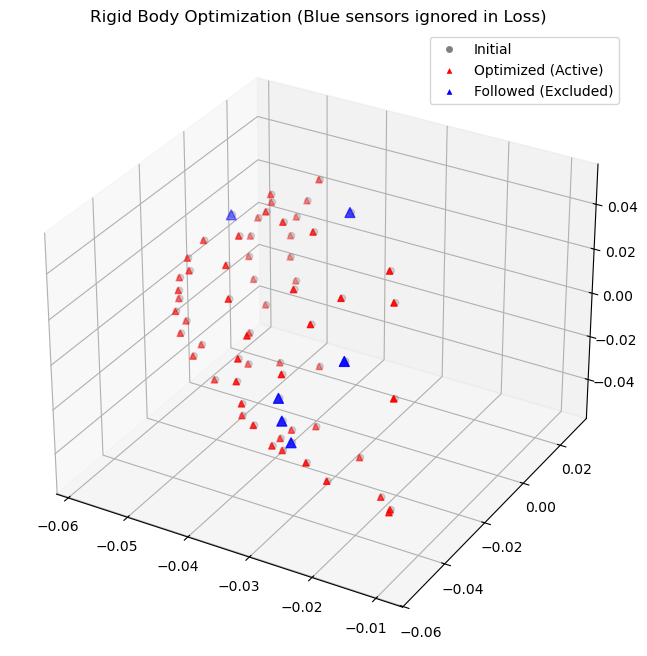

In [1]:
import os
import time
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ===============================================================
# 配置与初始化
# ===============================================================
DEVICE_ID = 1
device = torch.device(f"cuda:{DEVICE_ID}" if torch.cuda.is_available() else "cpu")
print(f"[INIT] 当前运行设备: {device}")

# --- 声学参数 ---
vs = 1500.0             # 声速
delta_time = 25e-9      # 采样间隔
t_start_idx = 1000      # 截取起始点
t_end_idx   = 2048      # 截取结束点
n_time_sub = t_end_idx - t_start_idx

# --- 优化参数 ---
TOTAL_EPOCHS = 100      
LR_ROT       = 1e-4      
LR_TRANS     = 1e-4      
SIGMA_FIXED  = 0.1e-3    

# --- 显存优化参数 ---
# 2080Ti 建议设为 8，兼顾速度和显存
MICRO_BATCH_SIZE = 5     

# --- !!! 排除列表 !!! ---
# 这些探头不参与 Loss 计算（不监督），但会随刚体一起移动并保存
# 索引基于 0-64 (即下采样后的索引)
EXCLUDE_IDS = [25, 31, 37, 50, 51, 64]

# ===============================================================
# 1. 数据加载
# ===============================================================
signal_path = "data/simulated_signal_rotated_120.txt"
init_array_path = "predicted_array_location_corrected.txt" 
CKPT_PATH = "checkpoints_01/epoch200_20260130_120009/model.pt" 
KEEP_RATIO = 0.002     

# --- A. 加载 Phantom 模型 ---
if os.path.exists(CKPT_PATH):
    print(f"[LOAD] Model: {CKPT_PATH}")
    ckpt = torch.load(CKPT_PATH, map_location=device)
    Pc_raw = ckpt["Pc_state"].to(device).contiguous().requires_grad_(False)
    
    GRID_SIZE = 256
    coords = (np.arange(GRID_SIZE) - (GRID_SIZE-1)/2.0) * 0.1e-3 
    xg, yg, zg = np.meshgrid(coords, coords, coords, indexing="ij")
    
    src_x_raw = torch.tensor(xg.ravel(), device=device, dtype=torch.float32).contiguous()
    src_y_raw = torch.tensor(yg.ravel(), device=device, dtype=torch.float32).contiguous()
    src_z_raw = torch.tensor(zg.ravel(), device=device, dtype=torch.float32).contiguous()
    
    n_keep = int(Pc_raw.numel() * KEEP_RATIO)
    val_top, idx_top = torch.topk(torch.abs(Pc_raw), n_keep)
    
    Pc_fixed = Pc_raw[idx_top].contiguous()
    xyz_src = torch.stack([src_x_raw[idx_top], src_y_raw[idx_top], src_z_raw[idx_top]], dim=1).contiguous()
else:
    raise FileNotFoundError(f"找不到模型文件: {CKPT_PATH}")

# --- B. 加载观测信号 ---
signals_full_raw = np.loadtxt(signal_path)
sel_step = 2
sel_idx = np.arange(0, signals_full_raw.shape[0], sel_step) # 129 -> 65
signals_sub_raw = signals_full_raw[sel_idx] 
# 截取时间窗
signals_target = torch.tensor(signals_sub_raw[:, t_start_idx:t_end_idx], dtype=torch.float32, device=device)
NUM_TOTAL_SENSORS = signals_target.shape[0] # 应该为 65

# --- C. 加载初始位置 ---
init_pos_np = np.loadtxt(init_array_path)
if init_pos_np.shape[0] != NUM_TOTAL_SENSORS:
    raise ValueError(f"坐标数量 ({init_pos_np.shape[0]}) 与 信号数量 ({NUM_TOTAL_SENSORS}) 不匹配！")
init_pos_tensor = torch.tensor(init_pos_np, dtype=torch.float32, device=device)

# --- D. 构建有效训练集索引 ---
# 生成 0 到 64
all_indices = np.arange(NUM_TOTAL_SENSORS)
# 排除指定的 ID
active_indices_np = np.setdiff1d(all_indices, EXCLUDE_IDS)
# 转为 Tensor 以便后续索引
active_indices_tensor = torch.tensor(active_indices_np, dtype=torch.long, device=device)

print(f"[CONFIG] 总探头数: {NUM_TOTAL_SENSORS}")
print(f"[CONFIG] 排除探头ID: {EXCLUDE_IDS}")
print(f"[CONFIG] 实际参与优化的探头数: {len(active_indices_np)}")

# ===============================================================
# 2. 核心函数与模型
# ===============================================================

def build_rotation_matrix(r):
    cx, sx = torch.cos(r[0]), torch.sin(r[0])
    cy, sy = torch.cos(r[1]), torch.sin(r[1])
    cz, sz = torch.cos(r[2]), torch.sin(r[2])
    Rx = torch.stack([torch.tensor([1.,0,0], device=device), torch.stack([torch.tensor(0., device=device), cx, -sx]), torch.stack([torch.tensor(0., device=device), sx, cx])])
    Ry = torch.stack([torch.stack([cy, torch.tensor(0., device=device), sy]), torch.tensor([0.,1,0], device=device), torch.stack([-sy, torch.tensor(0., device=device), cy])])
    Rz = torch.stack([torch.stack([cz, -sz, torch.tensor(0., device=device)]), torch.stack([sz, cz, torch.tensor(0., device=device)]), torch.tensor([0.,0,1], device=device)])
    return Rz @ Ry @ Rx

def vectorized_acoustic_simulation(sens_pos_batch, src_pos, Pc, t_start, n_time, dt, vs, a):
    # (Batch, N_src, 1) - (1, N_src, 1) -> (Batch, N_src, 3) -> norm -> (Batch, N_src)
    diff = sens_pos_batch.unsqueeze(1) - src_pos.unsqueeze(0) 
    r = torch.norm(diff, dim=2) + 1e-12 
    
    t_global = t_start + torch.arange(n_time, device=device, dtype=torch.float32) 
    
    # (Batch, N_src, T)
    rt = r.unsqueeze(2) - vs * (t_global * dt).reshape(1, 1, -1)
    exponent = torch.exp( - (rt**2) / (2.0 * a * a) )
    amplitude = Pc.reshape(1, -1, 1) * 0.5 * (rt / r.unsqueeze(2))
    
    signals = torch.sum(amplitude * exponent, dim=1)
    return signals

def batch_negative_correlation_loss(pred_batch, target_batch):
    pred_mean = pred_batch - pred_batch.mean(dim=1, keepdim=True)
    target_mean = target_batch - target_batch.mean(dim=1, keepdim=True)
    numerator = torch.sum(pred_mean * target_mean, dim=1)
    d1 = torch.norm(pred_mean, dim=1)
    d2 = torch.norm(target_mean, dim=1)
    correlation = numerator / (d1 * d2 + 1e-9)
    return 1.0 - correlation.mean()

class RigidArrayOptimizer(nn.Module):
    def __init__(self, init_points):
        super().__init__()
        self.centroid = torch.mean(init_points, dim=0, keepdim=True).detach()
        self.points_centered = (init_points - self.centroid).detach()
        
        # 优化参数: 旋转和平移
        self.rot_euler = nn.Parameter(torch.zeros(3, device=device)) 
        self.trans_vec = nn.Parameter(torch.zeros(3, device=device))
        
    def forward(self):
        R = build_rotation_matrix(self.rot_euler)
        # 这一步计算了 ALL 65 points 的位置
        p_final = (self.points_centered @ R.T) + self.centroid + self.trans_vec
        return p_final

# ===============================================================
# 3. 训练循环 (带 Mask)
# ===============================================================
print("\n" + "="*80)
print(f"开始优化 (Valid Sensors Only, Total: {len(active_indices_np)})")
print("="*80)

model = RigidArrayOptimizer(init_pos_tensor).to(device)
optimizer = torch.optim.Adam([
    {'params': model.rot_euler, 'lr': LR_ROT},
    {'params': model.trans_vec, 'lr': LR_TRANS}
])

loss_history = []
start_time = time.time()

for epoch in range(TOTAL_EPOCHS):
    optimizer.zero_grad()
    
    # 1. 获得当前所有65个探头的位置 (但只有 active indices 的位置会对 Loss 产生贡献)
    current_pos_all = model()
    
    total_loss_val = 0.0
    num_active = len(active_indices_np)
    
    # 2. 遍历 Active Indices
    for i in range(0, num_active, MICRO_BATCH_SIZE):
        # 获取当前批次在 active 列表中的索引范围
        start_k = i
        end_k = min(i + MICRO_BATCH_SIZE, num_active)
        
        # 获取真实的探头 ID (例如第0个active可能是ID 0, 第25个active可能是ID 26(跳过了25))
        batch_ids = active_indices_tensor[start_k:end_k]
        
        # 切片：只取参与训练的探头位置和真实信号
        pos_batch = current_pos_all[batch_ids]       
        target_batch = signals_target[batch_ids]     
        
        # 仿真
        pred_batch = vectorized_acoustic_simulation(
            pos_batch, xyz_src, Pc_fixed, 
            t_start_idx, n_time_sub, delta_time, vs, a=SIGMA_FIXED
        )
        
        # 计算 Loss
        loss_fragment = batch_negative_correlation_loss(pred_batch, target_batch)
        
        # 加权 & Backward
        weight = (end_k - start_k) / num_active
        weighted_loss = loss_fragment * weight
        weighted_loss.backward(retain_graph=True)
        
        total_loss_val += weighted_loss.item()
        del pred_batch, loss_fragment, weighted_loss
    
    optimizer.step()
    del current_pos_all
    
    loss_history.append(total_loss_val)
    
    if epoch % 2 == 0:
        r_deg = model.rot_euler.detach().cpu().numpy() * 180 / np.pi
        t_mm = model.trans_vec.detach().cpu().numpy() * 1000
        print(f"Epoch {epoch:04d} | Active_Loss: {total_loss_val:.6f} | "
              f"dRot(deg): {r_deg} | "
              f"dTrans(mm): {t_mm}")

print(f"\n[DONE] 优化耗时: {time.time()-start_time:.1f}s")

# ===============================================================
# 4. 结果保存 (保存所有 65 个探头)
# ===============================================================
final_pos_tensor = model().detach() # 获取最终所有点的坐标
final_pos_np = final_pos_tensor.cpu().numpy()

# 验证一下：即使是不训练的 ID (如 25)，位置也应该发生了变化(跟随刚体)
init_pos_cpu = init_pos_tensor.cpu().numpy()
check_idx = 25
move_dist = np.linalg.norm(final_pos_np[check_idx] - init_pos_cpu[check_idx]) * 1000
print(f"\n[CHECK] 排除探头 #{check_idx} 的跟随移动距离: {move_dist:.4f} mm")

# 保存
save_final_name = "predicted_array_location_finetuned_masked.txt"
np.savetxt(save_final_name, final_pos_np, fmt='%.8f', header="Finetuned x, y, z (meters) - All 65 Sensors")
print(f"[SAVE] 所有65个探头坐标(含未监督的)已保存至: {save_final_name}")

# 画图 (简单展示Active和Inactive的区别)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 所有的初始位置
ax.scatter(init_pos_cpu[:,0], init_pos_cpu[:,1], init_pos_cpu[:,2], c='gray', alpha=0.3, label='Initial')

# 所有的最终位置 (active 用红色，inactive 用蓝色)
# 创建颜色数组
colors = ['red'] * NUM_TOTAL_SENSORS
sizes = [20] * NUM_TOTAL_SENSORS
for idx in EXCLUDE_IDS:
    colors[idx] = 'blue' # 排除的显示为蓝色
    sizes[idx] = 50      # 排除的画大一点

ax.scatter(final_pos_np[:,0], final_pos_np[:,1], final_pos_np[:,2], c=colors, s=sizes, marker='^', label='Fine-Tuned')

# 仅创建一个图例
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', label='Initial'),
                   Line2D([0], [0], marker='^', color='w', markerfacecolor='red', label='Optimized (Active)'),
                   Line2D([0], [0], marker='^', color='w', markerfacecolor='blue', label='Followed (Excluded)')]
ax.legend(handles=legend_elements)
ax.set_title("Rigid Body Optimization (Blue sensors ignored in Loss)")
plt.show()